In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
def load_image(path):
    img = Image.open(path).resize((256, 256))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)
    return tf.convert_to_tensor(img, dtype=tf.float32)

content = load_image("content.jpg")
style = load_image("style.jpg")

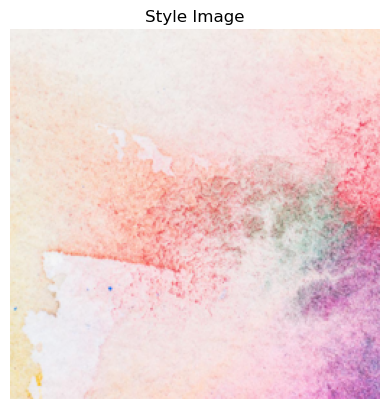

In [3]:
def imshow(img, title=None):
    img = tf.squeeze(img, axis=0)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

imshow(content, "Content Image")
imshow(style, "Style Image")

In [4]:
vgg = tf.keras.applications.VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

In [5]:
content_layer = 'block5_conv2'
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1'
]

outputs = [vgg.get_layer(name).output for name in style_layers + [content_layer]]
model = tf.keras.Model([vgg.input], outputs)

In [6]:
def get_features(image):
    image = image * 255.0
    preprocessed = tf.keras.applications.vgg19.preprocess_input(image)
    outputs = model(preprocessed)

    style_features = outputs[:-1]
    content_features = outputs[-1]

    return style_features, content_features

style_features, _ = get_features(style)
_, content_features = get_features(content)

In [7]:
target = tf.Variable(content)

In [8]:
def compute_loss(target):
    t_style, t_content = get_features(target)

    content_loss = tf.reduce_mean((t_content - content_features)**2)

    style_loss = 0
    for t_s, s_s in zip(t_style, style_features):
        style_loss += tf.reduce_mean((t_s - s_s)**2)

    total_loss = content_loss + 0.001 * style_loss
    return total_loss

In [9]:
optimizer = tf.optimizers.Adam(learning_rate=0.01)

for i in range(200):
    with tf.GradientTape() as tape:
        loss = compute_loss(target)

    grads = tape.gradient(loss, target)
    optimizer.apply_gradients([(grads, target)])

    if i % 50 == 0:
        print(f"Step {i}, Loss {loss.numpy()}")

Step 0, Loss 787.3427734375
Step 50, Loss 515.779296875
Step 100, Loss 455.73297119140625
Step 150, Loss 444.8000793457031


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.17382345..1.0814785].


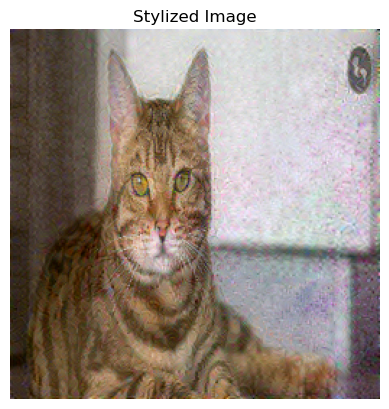

In [10]:
imshow(target, "Stylized Image")